# Exploración: establecimientos DENUE por municipio

Construye, a partir de los CSV en `datos/datos_limpios/denue_*.csv`, una tabla con una fila por municipio (clave INEGI) y una columna por cada código SCIAN de interés, con el número de establecimientos correspondiente.

In [1]:
import glob

import pandas as pd

## 1. Unir los CSV de `datos_limpios`

Los 4 archivos vienen del DENUE y están codificados en `latin-1` (no `utf-8`), por eso aparecen bytes inválidos si se leen con la codificación por defecto de pandas. `cve_ent` y `cve_mun` se leen como texto para no perder los ceros a la izquierda.

In [2]:
archivos = sorted(glob.glob("datos/datos_limpios/denue_*.csv"))
archivos

['datos/datos_limpios/denue_462111.csv',
 'datos/datos_limpios/denue_464111_464112.csv',
 'datos/datos_limpios/denue_624411_621113.csv',
 'datos/datos_limpios/denue_624412_62111.csv']

In [3]:
denue = pd.concat(
    (
        pd.read_csv(
            archivo,
            encoding="latin-1",
            dtype={"cve_ent": str, "cve_mun": str, "codigo_act": str},
        )
        for archivo in archivos
    ),
    ignore_index=True,
)

denue.shape

(144272, 15)

## 2. Construir el INEGI code municipal

Es la concatenación secuencial de `cve_ent` (2 dígitos) y `cve_mun` (3 dígitos) → 5 dígitos.

In [4]:
denue["inegi_code"] = denue["cve_ent"] + denue["cve_mun"]

assert denue["inegi_code"].str.len().eq(5).all()
denue[["cve_ent", "cve_mun", "inegi_code"]].drop_duplicates().head()

,cve_ent,cve_mun,inegi_code
0,01,001,01001
13,01,005,01005
41,01,003,01003
42,01,006,01006
43,01,011,01011


## 3. Filtrar a los códigos SCIAN de interés

Las descargas del DENUE se hicieron por *sector* de actividad, no por código específico, así que cada archivo trae varios códigos SCIAN del mismo sector. Los códigos de interés son:

| Código | Servicio |
| :---: | :--- |
| 462111 | Supermercados |
| 464111 | Farmacias sin minisúper |
| 464112 | Farmacias con minisúper |
| 624411 | Guarderías privadas |
| 624412 | Guarderías públicas |
| 621111 | Consultorios de medicina general del sector privado |
| 621113 | Consultorios de medicina especializada del sector privado |

In [5]:
denue["codigo_act"].value_counts()

codigo_act
464111    50918
621111    34635
621113    29679
464112    11707
624411     6977
462111     6482
624412     3874
Name: count, dtype: int64

In [6]:
codigos_interes = ["462111", "464111", "464112", "624411", "624412", "621111", "621113"]

denue_interes = denue[denue["codigo_act"].isin(codigos_interes)].copy()

denue_interes["codigo_act"].value_counts()

codigo_act
464111    50918
621111    34635
621113    29679
464112    11707
624411     6977
462111     6482
624412     3874
Name: count, dtype: int64

## 4. Agrupar por municipio y pivotear por código SCIAN

In [7]:
por_municipio = (
    denue_interes
    .pivot_table(
        index="inegi_code",
        columns="codigo_act",
        values="id",
        aggfunc="count",
        fill_value=0,
    )
)

por_municipio.shape

(2150, 7)

## 5. Completar el catálogo de los 2,469 municipios

El pivote anterior solo tiene filas para municipios con al menos un establecimiento de interés. Se completa contra el catálogo oficial de municipios (`datos/datos_crudos/marco_geo/catalogos/municipios.csv`, 2,469 municipios confirmados) para que los municipios sin establecimientos queden en 0 en vez de ausentes.

El resultado se guarda como `establecimientos_por_municipio.csv`.

In [8]:
catalogo = pd.read_csv(
    "datos/datos_crudos/marco_geo/catalogos/municipios.csv",
    encoding="latin-1",
    sep=";",
    skiprows=2,
    dtype=str,
)

catalogo["inegi_code"] = catalogo["Clave de Entidad"] + catalogo["Clave de Municipio"]

len(catalogo)

2469

In [9]:
resultado = (
    catalogo[["inegi_code"]]
    .merge(por_municipio, on="inegi_code", how="left")
    .fillna(0)
)

resultado = resultado[["inegi_code"] + codigos_interes]
resultado[codigos_interes] = resultado[codigos_interes].astype(int)

resultado.shape

(2469, 8)

In [10]:
assert resultado.shape[0] == 2469
assert list(resultado.columns) == ["inegi_code"] + codigos_interes
assert resultado[codigos_interes].sum().sum() == denue_interes.shape[0]

resultado.head()

,inegi_code,462111,464111,464112,624411,624412,621111,621113
0,01001,56,260,96,86,49,288,629
1,01002,0,10,5,0,2,5,0
2,01003,1,9,5,2,1,13,10
3,01004,0,4,2,0,0,1,1
4,01005,2,13,13,16,8,29,8


## 6. Guardar resultado

In [11]:
resultado.to_csv("datos/datos_limpios/establecimientos_por_municipio.csv", index=False)

## 7. Estadísticas descriptivas

In [13]:
resultado[codigos_interes].describe().T

,count,mean,std,min,25%,50%,75%,max
462111,2469.0,2.625354,11.116381,0.0,0.0,0.0,1.0,190.0
464111,2469.0,20.622924,69.717501,0.0,1.0,5.0,13.0,1288.0
464112,2469.0,4.741596,16.319107,0.0,0.0,1.0,3.0,273.0
624411,2469.0,2.825840,12.079644,0.0,0.0,0.0,1.0,193.0
624412,2469.0,1.569056,5.086428,0.0,0.0,0.0,1.0,69.0
621111,2469.0,14.027947,47.480966,0.0,0.0,2.0,9.0,706.0
621113,2469.0,12.020656,68.634971,0.0,0.0,0.0,1.0,1116.0


La media muy por encima de la mediana en las 7 columnas confirma una distribución muy sesgada: la mayoría de los municipios tiene pocos o ningún establecimiento, mientras que un pequeño número de municipios urbanos concentra la mayoría.

### Participación de cada código en el total nacional

In [13]:
totales_scian = resultado[codigos_interes].sum().sort_values(ascending=False)

pd.DataFrame({
    "total": totales_scian,
    "% del total": (totales_scian / totales_scian.sum() * 100).round(1),
})

,total,% del total
464111,50918,35.3
621111,34635,24.0
621113,29679,20.6
464112,11707,8.1
624411,6977,4.8
462111,6482,4.5
624412,3874,2.7


### Municipios sin ningún establecimiento de cada tipo

Qué tan común es que un municipio no tenga ni un solo establecimiento de cada categoría.

In [14]:
(resultado[codigos_interes].eq(0).mean() * 100).round(1).sort_values(ascending=False).rename("% de municipios en 0")

462111    71.7
621113    68.3
624411    67.7
624412    63.5
464112    47.3
621111    30.5
464111    16.8
Name: % de municipios en 0, dtype: float64

### Total de establecimientos (todas las categorías) por municipio

Suma de las 7 columnas por municipio, para ver qué tan concentrado está el total.

In [15]:
resultado["total"] = resultado[codigos_interes].sum(axis=1)

resultado["total"].describe()

count    2469.000000
mean       58.433374
std       211.936493
min         0.000000
25%         2.000000
50%         9.000000
75%        30.000000
max      3137.000000
Name: total, dtype: float64

## 8. Visualizaciones

In [16]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#e3e3e3",
    "grid.linewidth": 0.8,
})

# nombres cortos y colores fijos (paleta Okabe-Ito, segura para daltonismo) por código,
# en el mismo orden que codigos_interes para que cada código conserve siempre su color
nombres_scian = {
    "462111": "Supermercados",
    "464111": "Farmacias sin minisúper",
    "464112": "Farmacias con minisúper",
    "624411": "Guarderías privadas",
    "624412": "Guarderías públicas",
    "621111": "Consultorios medicina general",
    "621113": "Consultorios medicina especializada",
}
color_scian = dict(zip(
    codigos_interes,
    ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#56B4E9", "#F0E442"],
))

### Establecimientos totales por categoría

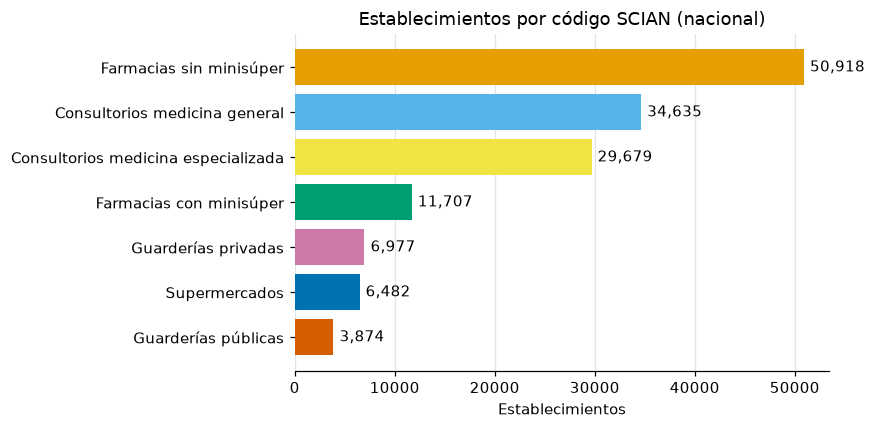

In [17]:
totales_ordenados = totales_scian.sort_values()
colores = [color_scian[codigo] for codigo in totales_ordenados.index]
etiquetas = [nombres_scian[codigo] for codigo in totales_ordenados.index]

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(etiquetas, totales_ordenados.values, color=colores)
ax.bar_label(barras, labels=[f"{v:,}" for v in totales_ordenados.values], padding=4)
ax.set_xlabel("Establecimientos")
ax.set_title("Establecimientos por código SCIAN (nacional)")
ax.grid(axis="x")
ax.set_axisbelow(True)
fig.tight_layout()

### Distribución del total de establecimientos por municipio

Eje y en escala logarítmica porque la distribución está muy concentrada en valores bajos, con una cola larga de municipios urbanos.

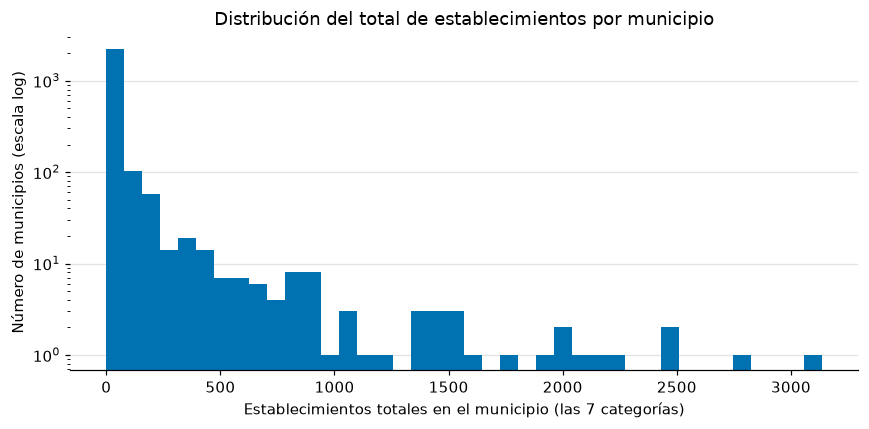

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(resultado["total"], bins=40, color=color_scian["462111"])
ax.set_yscale("log")
ax.set_xlabel("Establecimientos totales en el municipio (las 7 categorías)")
ax.set_ylabel("Número de municipios (escala log)")
ax.set_title("Distribución del total de establecimientos por municipio")
ax.grid(axis="y")
ax.set_axisbelow(True)
fig.tight_layout()

### Top 15 municipios con más establecimientos

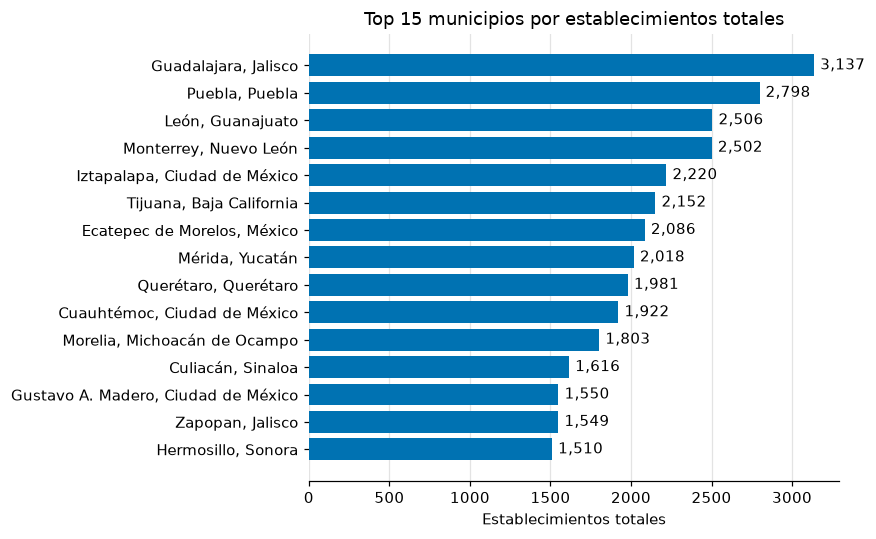

In [19]:
top15 = (
    resultado[["inegi_code", "total"]]
    .merge(
        catalogo[["inegi_code", "Nombre de Entidad", "Nombre de Municipio"]],
        on="inegi_code",
    )
    .nlargest(15, "total")
    .assign(etiqueta=lambda d: d["Nombre de Municipio"] + ", " + d["Nombre de Entidad"])
    .sort_values("total")
)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top15["etiqueta"], top15["total"], color=color_scian["462111"])
ax.bar_label(barras, labels=[f"{v:,}" for v in top15["total"]], padding=4)
ax.set_xlabel("Establecimientos totales")
ax.set_title("Top 15 municipios por establecimientos totales")
ax.grid(axis="x")
ax.set_axisbelow(True)
fig.tight_layout()

### Correlación entre categorías

Qué tanto tienden a coexistir dos tipos de establecimiento en el mismo municipio (correlación de Pearson entre sus conteos). Escala divergente: azul = correlación positiva, naranja = negativa, blanco = sin relación.

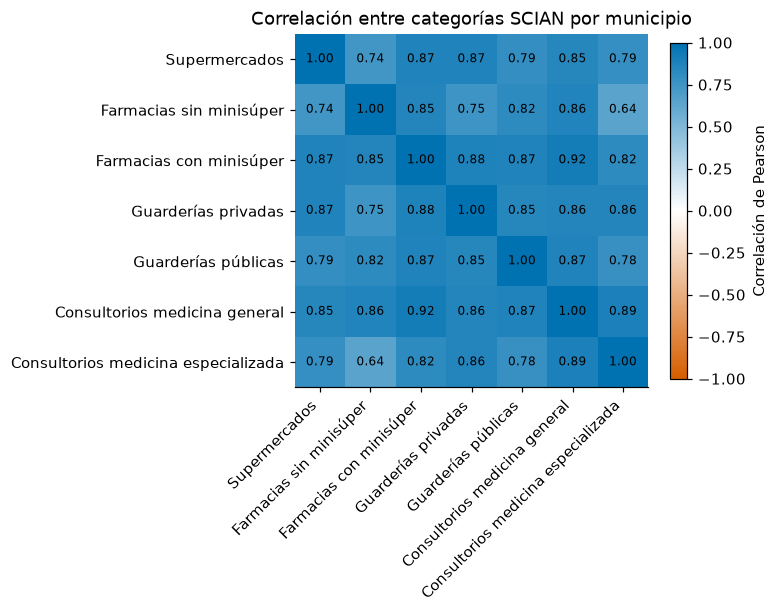

In [20]:
from matplotlib.colors import LinearSegmentedColormap

corr = resultado[codigos_interes].rename(columns=nombres_scian).corr()
diverging = LinearSegmentedColormap.from_list("diverging", ["#D55E00", "#FFFFFF", "#0072B2"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlación de Pearson", shrink=0.8)
ax.set_title("Correlación entre categorías SCIAN por municipio")
fig.tight_layout()